## Testing Methods in the `CONNECTIVITYTOOLS` Module

This Notebook serves as a platform to rigorously test the various methods included in the Python module `CONNECTIVITYTOOLS`, centered on the `Connectome` class for representing, analyzing, and visualizing brain connectivity data.

This module is particularly valuable for neuroimaging researchers working with structural and functional connectomes, enabling consistent construction, manipulation, and visualization of connectivity matrices across formats (arrays, CSV, HDF5).

The tests are organized into the following sections for clarity and ease of navigation:


---

* **🔷 0. [CONNECTIVITYTOOLS — Section 0: Creating a Connectome](#connectivitytools-create_connectome)**
  * 🔸 0.1. [Connectome](#connectivitytools-connectome_init): Create a Connectome from a matrix, or an empty placeholder object.
  * 🔸 0.2. [generate_connectome](#connectivitytools-generate_connectome): Generate a synthetic Connectome using random, modular, or distance-based methods.
  * 🔸 0.3. [from_csv / load_csv](#connectivitytools-from_csv): Create or populate a Connectome from a CSV connectivity matrix.
  * 🔸 0.4. [from_h5 / save_h5 / load_h5](#connectivitytools-from_h5): Round-trip a Connectome through an HDF5 file.
* **🔷 1. [CONNECTIVITYTOOLS — Section 1: Region Metadata (names, colors, coordinates, indices)](#connectivitytools-region_metadata)**
  * 🔸 1.1. [get_region_names / set_region_names](#connectivitytools-region_names): Get or set the region name labels.
  * 🔸 1.2. [get_region_colors / set_region_colors](#connectivitytools-region_colors): Get or set the region colors.
  * 🔸 1.3. [get_region_coordinates / set_region_coordinates](#connectivitytools-region_coordinates): Get or set the 3D coordinates of each region.
  * 🔸 1.4. [get_region_indices / set_region_indices](#connectivitytools-region_indices): Get or set the integer region index codes.
  * 🔸 1.5. [get_default_region_names / get_default_region_colors](#connectivitytools-default_region_metadata): Generate default region names/colors regardless of what is currently set.
  * 🔸 1.6. [load_colortable](#connectivitytools-load_colortable): Load region names/colors/indices from a dict, file, or ColorTableLoader.
* **🔷 2. [CONNECTIVITYTOOLS — Section 2: Connectivity Analysis & Manipulation](#connectivitytools-analysis)**
  * 🔸 2.1. [get_density](#connectivitytools-get_density): Compute the proportion of non-zero off-diagonal connections.
  * 🔸 2.2. [get_connectivity_stats](#connectivitytools-get_connectivity_stats): Compute summary statistics of the connectivity matrix.
  * 🔸 2.3. [set_diagonal_to_zero](#connectivitytools-set_diagonal_to_zero): Zero out the diagonal of the connectivity matrix.
  * 🔸 2.4. [set_symmetric](#connectivitytools-set_symmetric): Force the connectivity matrix to be symmetric.
  * 🔸 2.5. [threshold](#connectivitytools-threshold): Threshold the connectivity matrix by value or by target sparsity.
  * 🔸 2.6. [get_subnetwork](#connectivitytools-get_subnetwork): Extract a subnetwork containing a selected set of regions.
  * 🔸 2.7. [copy](#connectivitytools-copy): Create an independent deep copy of a Connectome.
* **🔷 3. [CONNECTIVITYTOOLS — Section 3: Visualization](#connectivitytools-visualization)**
  * 🔸 3.1. [plot_matrix](#connectivitytools-plot_matrix): Plot the connectivity matrix as a heatmap.
  * 🔸 3.2. [plot_circular_graph](#connectivitytools-plot_circular_graph): Plot the connectome as a circular graph layout.
  * 🔸 3.3. [visualize_3d](#connectivitytools-visualize_3d): Build an interactive 3D PyVista visualization of the connectome.
  * 🔸 3.4. [save_visualization](#connectivitytools-save_visualization): Render the 3D visualization and save it directly to an image file.
* **🔷 4. [CONNECTIVITYTOOLS — Section 4: Inspection Utilities](#connectivitytools-utilities)**
  * 🔸 4.1. [get_info](#connectivitytools-get_info): Print a formatted overview of the connectome.

<a id="connectivitytools-create_connectome"></a>
### 🔷 Section 0: Creating a Connectome
---

<a id="connectivitytools-connectome_init"></a>
##### 0.1. Connectome: Create a Connectome from a matrix, or an empty placeholder object.
---

In [ ]:
######################## Testing Connectome (creation) ###################################
import clabtoolkit.connectivitytools as cltconn
import numpy as np

print('Test 1: Creating a Connectome from a random connectivity matrix')
np.random.seed(0)
matrix = np.random.rand(10, 10)
conn = cltconn.Connectome(matrix, name='demo_matrix')
conn.get_info()
print('')

print('Test 2: Creating a connectome with specified region labels')
region_labels = [f'Region {i}' for i in range(10)]
conn_with_labels = cltconn.Connectome(matrix, name='demo_matrix_with_labels', region_names=region_labels)
print(conn_with_labels.get_region_names())
print('')   

print('Test 3: Creating a connectome with specified coordinate information')
coordinates = np.random.rand(10, 3)
conn_with_coords = cltconn.Connectome(matrix, name='demo_matrix_with_coords', region_coords=coordinates)
print(conn_with_coords.get_region_coordinates())
print('')


Test 1: Creating a Connectome from a random connectivity matrix
╔════════════════════════════════════════════════════════════════╗
║                      CONNECTOME OVERVIEW                       ║
╠════════════════════════════════════════════════════════════════╣
║ Name:    demo_matrix                                           ║
║ Type:    unknown                                               ║
║ Regions: 10                                                    ║
╠════════════════════════════════════════════════════════════════╣
║ MATRIX STATISTICS                                              ║
║   Shape:      10 × 10                                          ║
║   Range:      [0.0047,  0.9884]                                ║
║   Mean ± SD:  0.4728 ± 0.2883                                  ║
║   Density:    1.0000                                           ║
╠════════════════════════════════════════════════════════════════╣
║ COORDINATE RANGES                                              

<a id="connectivitytools-generate_connectome"></a>
##### 0.2. generate_connectome: Generate a synthetic Connectome using random, modular, or distance-based methods.
---

Test 1: Generate a random connectome


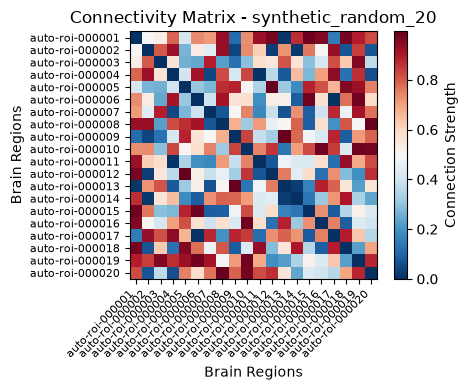


Test 2: Generate a modular (community-structured) connectome


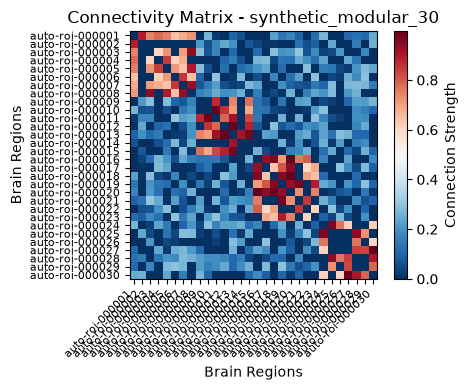


Test 3: Generate a distance-decayed connectome


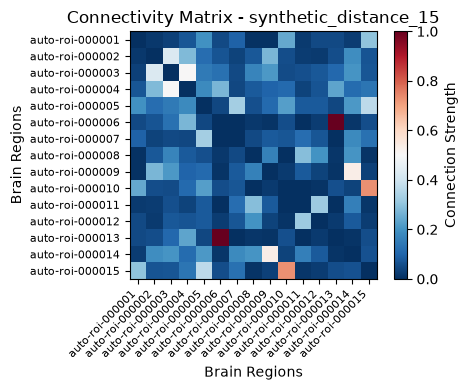

In [13]:
######################## Testing Connectome.generate_connectome ###################################
import clabtoolkit.connectivitytools as cltconn

print('Test 1: Generate a random connectome')
conn_random = cltconn.Connectome.generate_connectome(20, method='random', seed=0)
conn_random.plot_matrix(figsize=(5, 4))
print('')

print('Test 2: Generate a modular (community-structured) connectome')
conn_modular = cltconn.Connectome.generate_connectome(
    30, method='modular', n_modules=4, sparsity=0.3, seed=1
)
conn_modular.plot_matrix(figsize=(5, 4))
print('')

print('Test 3: Generate a distance-decayed connectome')
conn_distance = cltconn.Connectome.generate_connectome(
    15, method='distance', distance_decay=20.0, seed=2
)
conn_distance.plot_matrix(figsize=(5, 4))
print('')



<a id="connectivitytools-from_csv"></a>
##### 0.3. from_csv / load_csv: Create or populate a Connectome from a CSV connectivity matrix.
---

In [15]:
######################## Testing Connectome.from_csv / load_csv ###################################
import clabtoolkit.connectivitytools as cltconn
import numpy as np

print('Test 1: Round-tripping a connectome through a CSV file')
conn = cltconn.Connectome.generate_connectome(12, method='random', seed=3)
tmp_csv = '/tmp/test_connectome.csv'
np.savetxt(tmp_csv, conn.matrix, delimiter=',')

loaded = cltconn.Connectome.from_csv(tmp_csv, connectivity_type='structural')
loaded.get_info()
print('')

print('Test 2: Loading into an existing Connectome object with load_csv')
conn2 = cltconn.Connectome()
conn2.load_csv(tmp_csv, name='loaded_from_csv', connectivity_type='functional')
conn2.get_info()
print('')


Test 1: Round-tripping a connectome through a CSV file
╔════════════════════════════════════════════════════════════════╗
║                      CONNECTOME OVERVIEW                       ║
╠════════════════════════════════════════════════════════════════╣
║ Name:    test_connectome                                       ║
║ Type:    structural                                            ║
║ Regions: 12                                                    ║
╠════════════════════════════════════════════════════════════════╣
║ MATRIX STATISTICS                                              ║
║   Shape:      12 × 12                                          ║
║   Range:      [0.0000,  0.9998]                                ║
║   Mean ± SD:  0.4787 ± 0.3029                                  ║
║   Density:    1.0000                                           ║
╠════════════════════════════════════════════════════════════════╣
║ COORDINATE RANGES                                              ║
║   Not

<a id="connectivitytools-from_h5"></a>
##### 0.4. from_h5 / save_h5 / load_h5: Round-trip a Connectome through an HDF5 file.
---

Test 1: Saving a connectome to HDF5 and reloading it
Connectome saved to: /tmp/test_connectome.h5


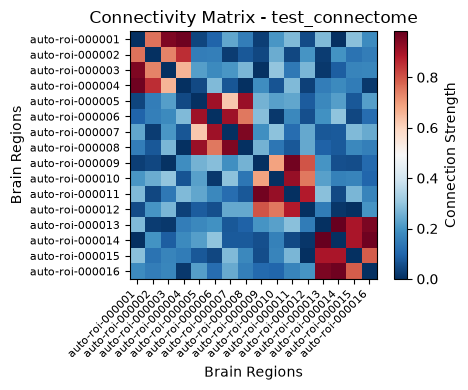


Test 2: Loading into an existing Connectome object with load_h5


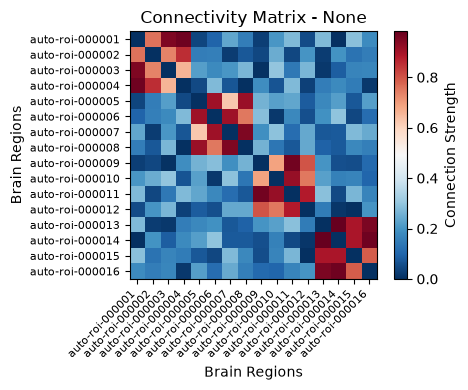

In [16]:
######################## Testing Connectome.from_h5 / save_h5 / load_h5 ###################################
import clabtoolkit.connectivitytools as cltconn

print('Test 1: Saving a connectome to HDF5 and reloading it')
conn = cltconn.Connectome.generate_connectome(16, method='modular', seed=4)
tmp_h5 = '/tmp/test_connectome.h5'
conn.save_h5(tmp_h5)

loaded = cltconn.Connectome.from_h5(tmp_h5)
loaded.plot_matrix(figsize=(5, 4))
print('')

print('Test 2: Loading into an existing Connectome object with load_h5')
conn2 = cltconn.Connectome()
conn2.load_h5(tmp_h5)
conn2.plot_matrix(figsize=(5, 4))


<a id="connectivitytools-region_metadata"></a>
### 🔷 Section 1: Region Metadata (names, colors, coordinates, indices)
---

<a id="connectivitytools-region_names"></a>
##### 1.1. get_region_names / set_region_names: Get or set the region name labels.
---

In [17]:
######################## Testing get_region_names / set_region_names ###################################
import clabtoolkit.connectivitytools as cltconn

conn = cltconn.Connectome.generate_connectome(5, seed=5)
print('Test 1: Default region names')
print(conn.get_region_names())

print('')
print('Test 2: Setting custom region names')
conn.set_region_names(['Frontal', 'Parietal', 'Temporal', 'Occipital', 'Insula'])
print(conn.get_region_names())


Test 1: Default region names
['auto-roi-000001', 'auto-roi-000002', 'auto-roi-000003', 'auto-roi-000004', 'auto-roi-000005']

Test 2: Setting custom region names
['Frontal', 'Parietal', 'Temporal', 'Occipital', 'Insula']


<a id="connectivitytools-region_colors"></a>
##### 1.2. get_region_colors / set_region_colors: Get or set the region colors.
---

In [18]:
######################## Testing get_region_colors / set_region_colors ###################################
import clabtoolkit.connectivitytools as cltconn

conn = cltconn.Connectome.generate_connectome(5, seed=6)
print('Test 1: Default region colors')
print(conn.get_region_colors())

print('')
print('Test 2: Setting custom region colors (hex strings)')
conn.set_region_colors(['#ff0000', '#00ff00', '#0000ff', '#ffff00', '#ff00ff'])
print(conn.get_region_colors())


Test 1: Default region colors
['#b14e12', '#6dae3d', '#1bcaa3', '#1d1f69', '#990a80']

Test 2: Setting custom region colors (hex strings)
['#ff0000', '#00ff00', '#0000ff', '#ffff00', '#ff00ff']


<a id="connectivitytools-region_coordinates"></a>
##### 1.3. get_region_coordinates / set_region_coordinates: Get or set the 3D coordinates of each region.
---

In [19]:
######################## Testing get_region_coordinates / set_region_coordinates ###################################
import clabtoolkit.connectivitytools as cltconn
import numpy as np

conn = cltconn.Connectome.generate_connectome(5, seed=7)
print('Test 1: Auto-generated (spherical) coordinates')
print(conn.get_region_coordinates())

print('')
print('Test 2: Setting custom coordinates')
custom_coords = np.random.rand(5, 3) * 100
conn.set_region_coordinates(custom_coords)
print(conn.get_region_coordinates())


Test 1: Auto-generated (spherical) coordinates
[[  0.12455111  30.24751964 -27.75603021]
 [-31.57242667 -16.11856229 -35.1549237 ]
 [  1.94754593  43.39831058 -15.93843335]
 [-30.53536315  24.10654306  17.56344117]
 [  5.60505207 -49.4745434   -1.55536836]]

Test 2: Setting custom coordinates
[[22.73624491  6.88519645 70.5710044 ]
 [39.52332435 31.08399771 71.86263903]
 [33.59775423 72.77712732 81.51993953]
 [21.76628435 97.38186968 16.23579479]
 [29.08409067 17.97952908 34.55056564]]


<a id="connectivitytools-region_indices"></a>
##### 1.4. get_region_indices / set_region_indices: Get or set the integer region index codes.
---

In [20]:
######################## Testing get_region_indices / set_region_indices ###################################
import clabtoolkit.connectivitytools as cltconn

conn = cltconn.Connectome.generate_connectome(5, seed=8)
print('Test 1: Default region indices')
print(conn.get_region_indices())

print('')
print('Test 2: Setting custom region indices')
conn.set_region_indices([101, 102, 103, 104, 105])
print(conn.get_region_indices())


Test 1: Default region indices
[0, 1, 2, 3, 4]

Test 2: Setting custom region indices
[101, 102, 103, 104, 105]


<a id="connectivitytools-default_region_metadata"></a>
##### 1.5. get_default_region_names / get_default_region_colors: Generate default region names/colors regardless of what is currently set.
---

In [21]:
######################## Testing get_default_region_names / get_default_region_colors ###################################
import clabtoolkit.connectivitytools as cltconn

conn = cltconn.Connectome.generate_connectome(5, seed=9)

print('Test 1: get_default_region_names (ignores any custom names already set)')
conn.set_region_names(['A', 'B', 'C', 'D', 'E'])
print('Custom names:', conn.get_region_names())
print('Default names:', conn.get_default_region_names())

print('')
print('Test 2: get_default_region_colors')
print(conn.get_default_region_colors())


Test 1: get_default_region_names (ignores any custom names already set)
Custom names: ['A', 'B', 'C', 'D', 'E']
Default names: ['auto-roi-000001', 'auto-roi-000002', 'auto-roi-000003', 'auto-roi-000004', 'auto-roi-000005']

Test 2: get_default_region_colors
[[210  93  25]
 [ 93 160  41]
 [ 27 210 167]
 [ 60  64 172]
 [153   7 129]]


<a id="connectivitytools-load_colortable"></a>
##### 1.6. load_colortable: Load region names/colors/indices from a dict, file, or ColorTableLoader.
---

In [23]:
######################## Testing load_colortable ###################################
import clabtoolkit.connectivitytools as cltconn
import clabtoolkit.colorstools as cltcol

conn = cltconn.Connectome.generate_connectome(5, seed=10)

print('Test 1: Loading region colors/names/index from a dictionary')
ctab = {
    'index': [1, 2, 3, 4, 5],
    'name': ['Region_A', 'Region_B', 'Region_C', 'Region_D', 'Region_E'],
    'color': ['#ff0000', '#00ff00', '#0000ff', '#ffff00', '#ff00ff'],
}
conn.load_colortable(ctab)
print('Names:', conn.get_region_names())
print('Colors:', conn.get_region_colors())
print('Indices:', conn.get_region_indices())

print('')
print('Test 2: Loading from a ColorTableLoader object')
loader = cltcol.ColorTableLoader(ctab)
conn.load_colortable(loader)
print('Names:', conn.get_region_names())
print('Colors:', conn.get_region_colors())
print('Indices:', conn.get_region_indices())
print('')


Test 1: Loading region colors/names/index from a dictionary
Names: ['Region_A', 'Region_B', 'Region_C', 'Region_D', 'Region_E']
Colors: ['#ff0000', '#00ff00', '#0000ff', '#ffff00', '#ff00ff']
Indices: [1, 2, 3, 4, 5]

Test 2: Loading from a ColorTableLoader object
Names: ['Region_A', 'Region_B', 'Region_C', 'Region_D', 'Region_E']
Colors: ['#ff0000', '#00ff00', '#0000ff', '#ffff00', '#ff00ff']
Indices: [1, 2, 3, 4, 5]



<a id="connectivitytools-analysis"></a>
### 🔷 Section 2: Connectivity Analysis & Manipulation
---

<a id="connectivitytools-get_density"></a>
##### 2.1. get_density: Compute the proportion of non-zero off-diagonal connections.
---

Test 1: Density of a dense random connectome
Density: 1.000


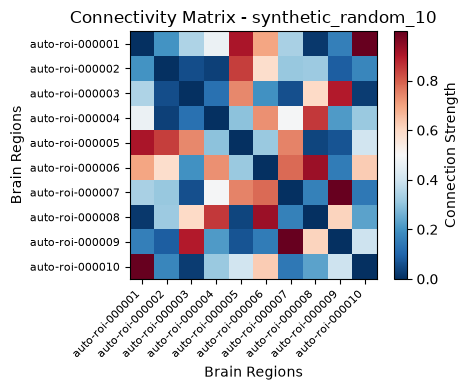


Test 2: Density of a sparse connectome
Density: 0.200


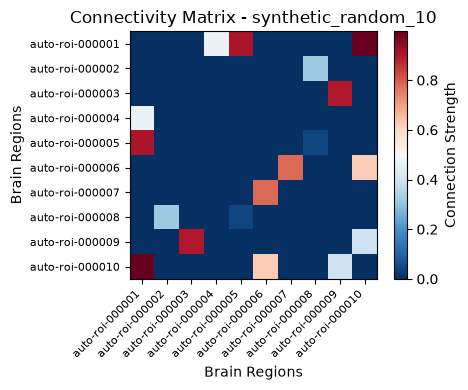

In [25]:
######################## Testing get_density ###################################
import clabtoolkit.connectivitytools as cltconn

print('Test 1: Density of a dense random connectome')
conn_dense = cltconn.Connectome.generate_connectome(10, method='random', seed=11)
print(f'Density: {conn_dense.get_density():.3f}')
conn_dense.plot_matrix(figsize=(5, 4))

print('')
print('Test 2: Density of a sparse connectome')
conn_sparse = cltconn.Connectome.generate_connectome(10, method='random', sparsity=0.8, seed=11)
print(f'Density: {conn_sparse.get_density():.3f}')
conn_sparse.plot_matrix(figsize=(5, 4))
print('')


<a id="connectivitytools-get_connectivity_stats"></a>
##### 2.2. get_connectivity_stats: Compute summary statistics of the connectivity matrix.
---

In [26]:
######################## Testing get_connectivity_stats ###################################
import clabtoolkit.connectivitytools as cltconn

conn = cltconn.Connectome.generate_connectome(10, seed=12)
stats = conn.get_connectivity_stats()
for key, value in stats.items():
    print(f'{key}: {value}')


n_regions: 10
matrix_shape: (10, 10)
min_strength: 0.0
max_strength: 0.9492661211569702
mean_strength: 0.5196597061619835
std_strength: 0.3166669455681125
density: 1.0
node_strengths: [5.3240127  5.48718835 4.26327864 4.70896343 6.12795898 6.2456468
 5.50503757 5.12862796 5.49115262 3.68410357]
coord_ranges: {'x': (np.float64(-27.4489047932654), np.float64(36.88172128678949)), 'y': (np.float64(-41.44542919228721), np.float64(37.75498433786028)), 'z': (np.float64(-35.15977932373501), np.float64(26.76369426333317))}


<a id="connectivitytools-set_diagonal_to_zero"></a>
##### 2.3. set_diagonal_to_zero: Zero out the diagonal of the connectivity matrix.
---

In [27]:
######################## Testing set_diagonal_to_zero ###################################
import clabtoolkit.connectivitytools as cltconn
import numpy as np

conn = cltconn.Connectome.generate_connectome(5, seed=13)
conn.matrix[np.diag_indices(5)] = 99  # force a non-zero diagonal for the demo
print('Diagonal before:', np.diag(conn.matrix))

conn.set_diagonal_to_zero()
print('Diagonal after:', np.diag(conn.matrix))


Diagonal before: [99. 99. 99. 99. 99.]
Diagonal after: [0. 0. 0. 0. 0.]


<a id="connectivitytools-set_symmetric"></a>
##### 2.4. set_symmetric: Force the connectivity matrix to be symmetric.
---

In [29]:
######################## Testing set_symmetric ###################################
import clabtoolkit.connectivitytools as cltconn

conn = cltconn.Connectome.generate_connectome(5, method='random', symmetric=False, seed=14)
print('Is symmetric before:', (conn.matrix == conn.matrix.T).all())

conn.set_symmetric()
print('Is symmetric after:', (conn.matrix == conn.matrix.T).all())


Is symmetric before: False
Is symmetric after: True


<a id="connectivitytools-threshold"></a>
##### 2.5. threshold: Threshold the connectivity matrix by value or by target sparsity.
---

In [31]:
######################## Testing threshold ###################################
import clabtoolkit.connectivitytools as cltconn
import numpy as np

conn = cltconn.Connectome.generate_connectome(10, seed=15)

print('Test 1: Value thresholding')
conn_val = conn.threshold(method='value', threshold=0.5)
print(f'Density after value threshold: {conn_val.get_density():.3f}')

print('')
print('Test 2: Sparsity thresholding (keep top 20% of connections)')
conn_sparsity = conn.threshold(method='sparsity', threshold=0.2)
print(f'Density after sparsity threshold: {conn_sparsity.get_density():.3f}')

print('')
print('Test 3: In-place thresholding with binarization')
conn_copy = conn.copy()
conn_copy.threshold(method='value', threshold=0.5, binarize=True, copy=False)
print('Unique values after binarizing:', np.unique(conn_copy.matrix))


Test 1: Value thresholding
Density after value threshold: 0.556

Test 2: Sparsity thresholding (keep top 20% of connections)
Density after sparsity threshold: 0.200

Test 3: In-place thresholding with binarization
Unique values after binarizing: [0. 1.]


<a id="connectivitytools-get_subnetwork"></a>
##### 2.6. get_subnetwork: Extract a subnetwork containing a selected set of regions.
---

In [32]:
######################## Testing get_subnetwork ###################################
import clabtoolkit.connectivitytools as cltconn

conn = cltconn.Connectome.generate_connectome(10, seed=16)
print('Original:', conn)

print('')
print('Test 1: Extracting a subnetwork (copy)')
sub = conn.get_subnetwork([0, 1, 2, 3, 4])
print(sub)
print('Sub region names:', sub.get_region_names())
print('Sub region colors:', sub.get_region_colors())


Original: Connectome(name='synthetic_random_10', type='unknown', n_regions=10, density=1.000)

Test 1: Extracting a subnetwork (copy)
Connectome(name='synthetic_random_10_subnetwork', type='unknown', n_regions=5, density=1.000)
Sub region names: ['auto-roi-000001', 'auto-roi-000002', 'auto-roi-000003', 'auto-roi-000004', 'auto-roi-000005']
Sub region colors: ['#a66b24', '#859338', '#349f0f', '#428659', '#2bd4cb']


<a id="connectivitytools-copy"></a>
##### 2.7. copy: Create an independent deep copy of a Connectome.
---

In [33]:
######################## Testing copy ###################################
import clabtoolkit.connectivitytools as cltconn

conn = cltconn.Connectome.generate_connectome(6, seed=17)
conn_copy = conn.copy()

print('Copy is a different object:', conn_copy is not conn)
print('Copy has the same matrix values:', (conn_copy.matrix == conn.matrix).all())

conn_copy.matrix[0, 1] = 999
print('Modifying the copy does not affect the original:', conn.matrix[0, 1] != 999)


Copy is a different object: True
Copy has the same matrix values: True
Modifying the copy does not affect the original: True


<a id="connectivitytools-visualization"></a>
### 🔷 Section 3: Visualization
---

<a id="connectivitytools-plot_matrix"></a>
##### 3.1. plot_matrix: Plot the connectivity matrix as a heatmap.
---

Test 1: Plotting the raw connectivity matrix


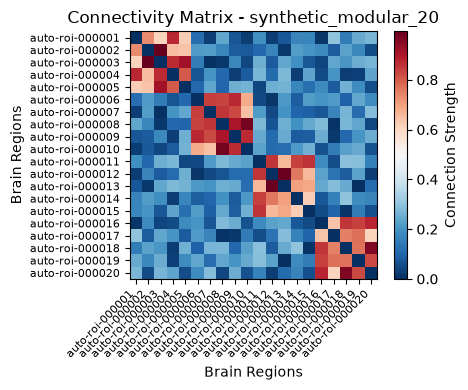

Test 2: Plotting with a threshold and log scale


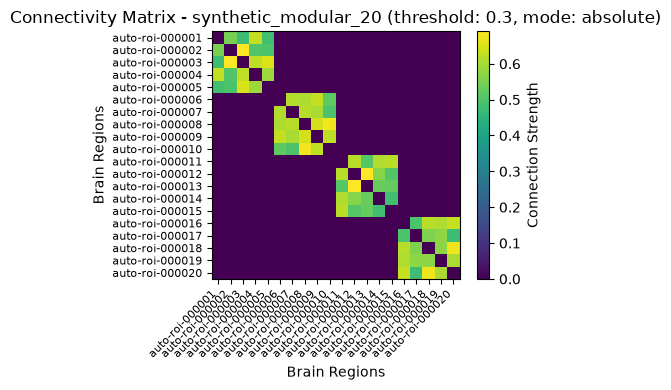

In [35]:
######################## Testing plot_matrix ###################################
import clabtoolkit.connectivitytools as cltconn

conn = cltconn.Connectome.generate_connectome(20, method='modular', seed=18)

print('Test 1: Plotting the raw connectivity matrix')
conn.plot_matrix(figsize=(5, 4))

print('Test 2: Plotting with a threshold and log scale')
conn.plot_matrix(threshold=0.3, log_scale=True, cmap='viridis', figsize=(5, 4))


<a id="connectivitytools-plot_circular_graph"></a>
##### 3.2. plot_circular_graph: Plot the connectome as a circular graph layout.
---

Test 1: Circular graph sized by connection strength


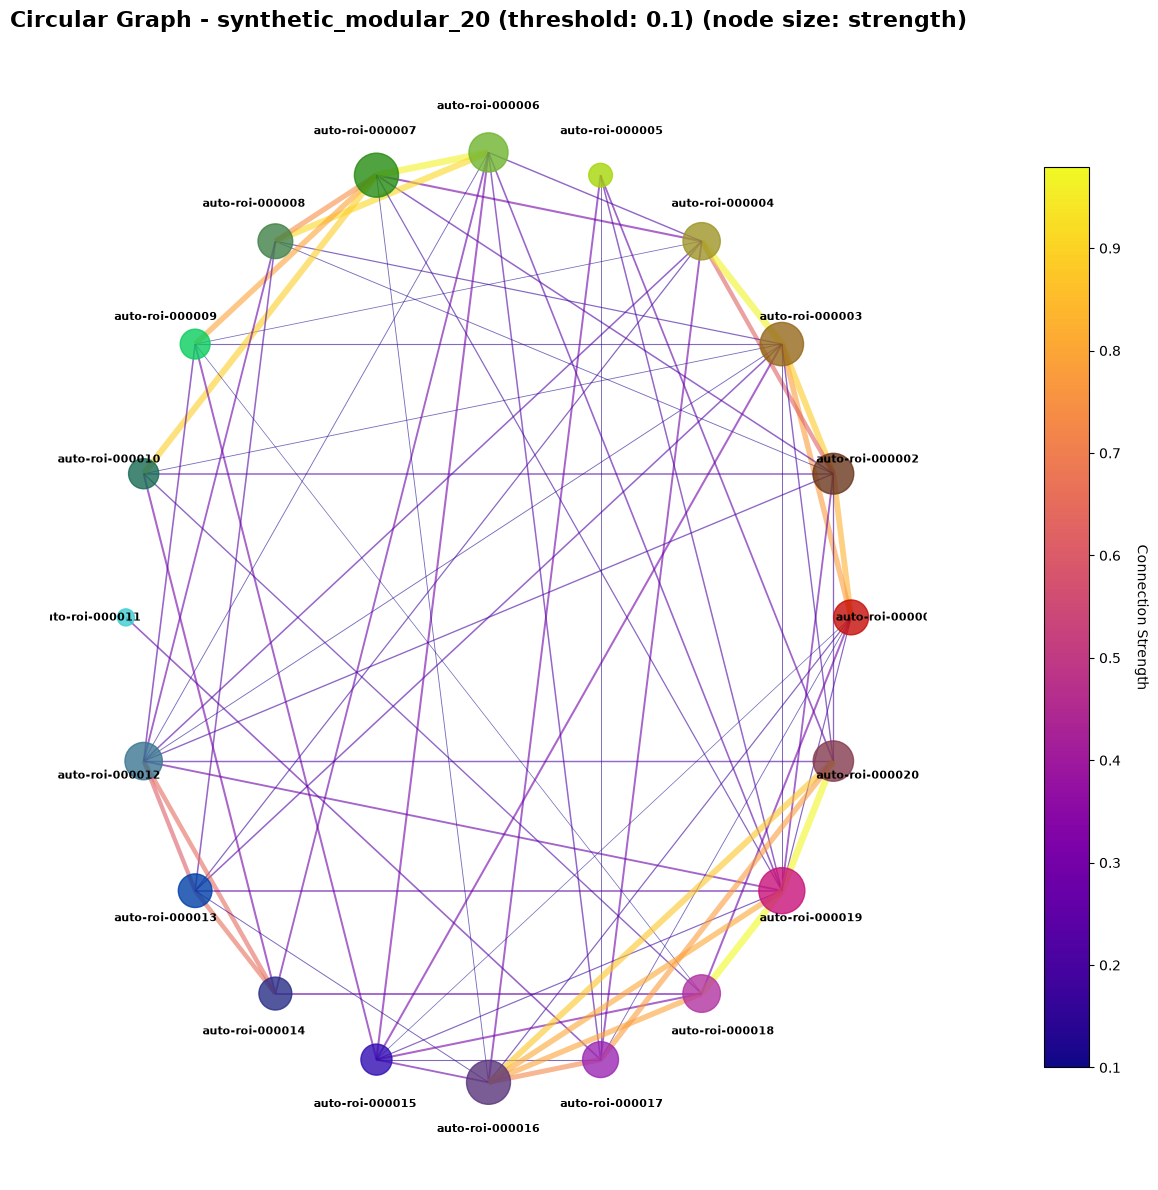

Test 2: Circular graph sized by node degree, without labels


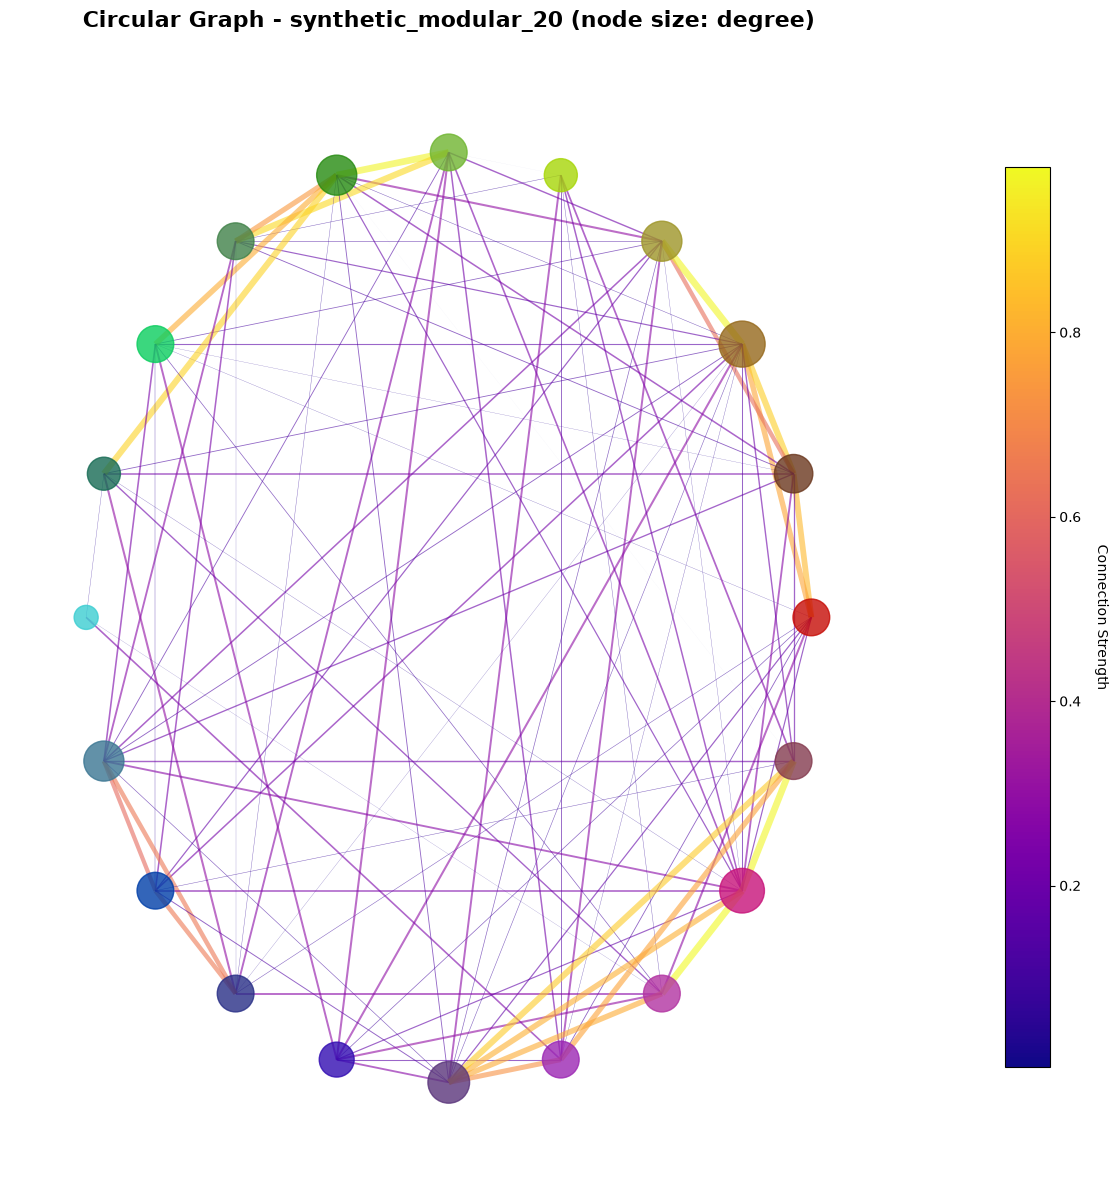

In [36]:
######################## Testing plot_circular_graph ###################################
import clabtoolkit.connectivitytools as cltconn

conn = cltconn.Connectome.generate_connectome(20, method='modular', sparsity=0.5, seed=19)

print('Test 1: Circular graph sized by connection strength')
conn.plot_circular_graph(node_size_property='strength', threshold=0.1)

print('Test 2: Circular graph sized by node degree, without labels')
conn.plot_circular_graph(node_size_property='degree', show_labels=False)


<a id="connectivitytools-visualize_3d"></a>
##### 3.3. visualize_3d: Build an interactive 3D PyVista visualization of the connectome.
---

In [3]:
######################## Testing visualize_3d ###################################
import clabtoolkit.connectivitytools as cltconn
import pyvista as pv

# Render off-screen so this cell runs headlessly; remove this line for an
# interactive window in a local Jupyter session.
pv.OFF_SCREEN = True

conn = cltconn.Connectome.generate_connectome(20, method='distance', seed=20)

print('Test 1: Creating a 3D PyVista visualization')
plotter = conn.visualize_3d(node_size_property='strength', show_labels=False, notebook=True)
plotter.show()



Test 1: Creating a 3D PyVista visualization


Widget(value='<iframe src="http://localhost:46853/index.html?ui=P_0x730ca1b4df70_1&reconnect=auto" class="pyvi…

<a id="connectivitytools-save_visualization"></a>
##### 3.4. save_visualization: Render the 3D visualization and save it directly to an image file.
---

In [4]:
######################## Testing save_visualization ###################################
import clabtoolkit.connectivitytools as cltconn
import pyvista as pv

pv.OFF_SCREEN = True

conn = cltconn.Connectome.generate_connectome(15, method='random', seed=21)

print('Test 1: Saving a 3D visualization screenshot to disk')
conn.save_visualization('/tmp/test_connectome_3d.png', node_size_property='degree')
print('Saved to /tmp/test_connectome_3d.png')


Test 1: Saving a 3D visualization screenshot to disk
Saved to /tmp/test_connectome_3d.png


<a id="connectivitytools-utilities"></a>
### 🔷 Section 4: Inspection Utilities
---

<a id="connectivitytools-get_info"></a>
##### 4.1. get_info: Print a formatted overview of the connectome.
---

In [5]:
######################## Testing get_info ###################################
import clabtoolkit.connectivitytools as cltconn

conn = cltconn.Connectome.generate_connectome(30, method='modular', seed=22)
conn.get_info()


╔════════════════════════════════════════════════════════════════╗
║                      CONNECTOME OVERVIEW                       ║
╠════════════════════════════════════════════════════════════════╣
║ Name:    synthetic_modular_30                                  ║
║ Type:    unknown                                               ║
║ Regions: 30                                                    ║
╠════════════════════════════════════════════════════════════════╣
║ MATRIX STATISTICS                                              ║
║   Shape:      30 × 30                                          ║
║   Range:      [0.0000,  0.9845]                                ║
║   Mean ± SD:  0.2873 ± 0.2848                                  ║
║   Density:    1.0000                                           ║
╠════════════════════════════════════════════════════════════════╣
║ COORDINATE RANGES                                              ║
║   X:  [  -40.13,    35.15]                                  